# Inner-Event Shape & Cell-Read Diagnostics — Step 1-2 Trust & Posture

**Status:** diagnostic, not a pricing input  ·  **Catalog:** `eagle-i-45min` (default)  ·  **Rebuilt:** 2026-06-22

This notebook is the **Solution** layer for Steps 1-2 of the outage-pricing pipeline.
It attaches a two-part *cell read* to every (county, duration-threshold) cell so a
writer or carrier can see, at a glance, **how much to trust the number** and **which
way it is biased**.

```text
 STAGE     Step 1-2:  county 15-min snapshots  ->  per-customer frequency  lambda_customer
 QUESTION  "Are these numbers over- or under-stated, and can I trust them
            county-by-county?"
 SOLUTION  cell_read(fips, T) = TRUST  +  POSTURE         <-- this notebook
```

The read is deliberately **two axes**, because "do I trust it" and "which way is it
biased" are different questions an underwriter asks:

```text
 TRUST   "can we believe  lambda_county x multiplier ?"      weakest-link min() of:
   |- C_source   per-county source coverage (observed yrs / window) + known-gap flags
   |- C_sample   enough qualifying events  (Poisson rel. error ~ 1/sqrt(n))
   `- C_evt      eventization stability: lambda spread across the 30/45/60 catalogs
        ->  Strong / Medium / Thin

 POSTURE "are we conservative here, and where does it break down?"   (= the A011 read)
   (1) cushion LEVEL (absolute, by duration): how much built-in margin is here
        short T 2h/4h  ->  runs close       -> VERIFY (the "undercutting short?" zone)
        long  T 8h/12h+->  well-cushioned    -> conservative (mean over-states ~2-3x)
   (2) cushion TILT  (within-T vs peers, SECONDARY analyst detail): spikier / typical / flatter
```

Reported **alongside** the read (shown, not scored): `mm_ratio` (mean/median multiplier
gap), `pct_mcc_p90/p99` (tail), and the coverage gate.

## How to read the labels (plain language)

**TRUST — "how hard can I lean on this number?"** The **worst of three plain checks**
(weakest link — one bad check caps it, because a great event count can't rescue a known
data gap):

```text
 check       the question it answers
 ──────────────────────────────────────────────────────────────────────
 coverage    Did we watch this county long enough, with no known data
             blackouts?  (e.g. Texas lost reporting in 2016)              [C_source]
 volume      Are there enough qualifying outages to trust a rate — not
             just a handful?                                              [C_sample]
 stability   Does the number stay put when we change how snapshots get
             stitched into events?  If it swings, we trust it less.       [C_evt]

 Strong  ->  all three pass.  Quote on this number with normal confidence.
 Medium  ->  one check is soft (fewer events / partial coverage / some
             stitching sensitivity).  Usable — quote with a caveat, monitor.
 Thin    ->  a check fails (too few events, a known source gap, or unstable).
             Don't lean on it alone — route to review or fall back to county.
```

**POSTURE — "are we conservative here, and where does that break down?"** (Chris's question.)
Two layers:

```text
 (1) CUSHION LEVEL — absolute, by duration: how much built-in margin (A011 over-statement) is here
       short T (2h/4h)   ->  runs close      ->  VERIFY ("are we undercutting short?" zone)
       mid               ->  some cushion
       long  T (8h/12h+) ->  well-cushioned  ->  conservative (mean over-states ~2-3x)

 (2) CUSHION TILT  — within-T vs peers (SECONDARY, analyst detail — lives in the per-county CSV):
       spikier than peers -> extra cushion · flatter -> less · typical -> no lean
```

Two different questions: **TRUST = how much to believe it; POSTURE = how conservative it is
(LEVEL, by duration) and how it compares to peers (TILT).** Posture never moves the price by
itself. Canonical definition: [`cell_read_fundamentals.md`](../docs/methodology/02_per_customer/cell_read_fundamentals.md).

## What the real catalog allows — and what it doesn't

Three of the originally-proposed five shape proxies do **not** survive the real
`events.parquet`. The catalog stores only `min / mean / max / n_snapshots` per event
(no within-event percentiles, no 15-min path), and:

```text
 min_customers       median = 1 at EVERY T; <=1 for 57-67% of events  -> DEAD
   -> restoration-tail proxy fires on almost everything (degenerate)
 observed_fraction   median = 1.000; < 0.75 for only 0.1-0.6% of events -> INERT
   -> bridge-heavy is a rare QA flag, not a posture driver
 peak_to_mean        median 1.54 -> 7.26 as T 2h -> 24h  -> CONFOUNDED by duration
   -> only meaningful read as a percentile WITHIN T
```

So from event **summaries**, `peak_to_mean` is the *only* robust within-event shape
signal. Real plateau / tail detection needs the 15-min paths preserved — a later,
targeted step, not Gen-1. The cell read is built to be honest about that ceiling.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
# robust repo-root: works whether executed from notebooks/ or repo root
while not os.path.isdir("price_engine/catalogs") and os.getcwd() != "/":
    os.chdir("..")
print("cwd:", os.getcwd())

CATALOGS = ["eagle-i-30min", "eagle-i-45min", "eagle-i-60min"]
DEFAULT  = "eagle-i-45min"
TS = [2, 4, 8, 12, 24]
PCL = "curated_outage_data/outputs/per_customer_rate/per_customer_lambda__{}.parquet"
EVENTS = "price_engine/catalogs/{}/data/events.parquet".format(DEFAULT)
OUT = "notebooks/outputs/inner_event_shape_diagnostics"
os.makedirs(OUT, exist_ok=True)

pcl = {c: pd.read_parquet(PCL.format(c)) for c in CATALOGS}
base = pcl[DEFAULT][["fips","T","n_events_total","n_events_qualifying","observation_years",
                     "mcc","lambda_county","multiplier_mean","multiplier_median",
                     "pct_mcc_p90","pct_mcc_p99","coverage_gate_status"]].copy()
ev = pd.read_parquet(EVENTS, columns=["fips","year","duration_hours","max_customers","mean_customers"])
print(f"per-customer cells: {len(base):,}   |   events ({DEFAULT}): {len(ev):,}")

cwd: /Users/divy/code/work/infrasure_git_codes/outage_pricing


per-customer cells: 15,450   |   events (eagle-i-45min): 13,190,684


In [2]:
# ---------- TRUST components ----------
# C_evt : eventization stability = relative spread of lambda_county across 30/45/60
lam = base[["fips","T"]].copy()
for c in CATALOGS:
    lam = lam.merge(pcl[c][["fips","T","lambda_county"]].rename(columns={"lambda_county": c[-5:]}),
                    on=["fips","T"], how="left")
L = lam[[c[-5:] for c in CATALOGS]]
lmed = L.median(axis=1)
base["evt_spread"] = (L.max(axis=1) - L.min(axis=1)) / lmed.where(lmed > 1e-9, np.nan)

# C_source : per-county coverage (distinct observed years / full window) + known-gap flags
YR_LO, YR_HI = int(ev.year.min()), int(ev.year.max()); EXPECTED = YR_HI - YR_LO + 1
print(f"source window: {YR_LO}-{YR_HI} ({EXPECTED} yrs)")
cov = ev.groupby("fips").agg(n_obs_years=("year","nunique")).reset_index()
cov["C_source"] = (cov.n_obs_years / EXPECTED).clip(0, 1)
_tx2016 = set(ev.loc[ev.year == 2016, "fips"].unique())
cov.loc[((cov.fips//1000) == 48) & (~cov.fips.isin(_tx2016)), "C_source"] *= 0.5   # TX-2016 gap
cov.loc[(cov.fips >= 9110) & (cov.fips <= 9190), "C_source"] = 0.25                 # CT-2025 planning regions
base = base.merge(cov[["fips","n_obs_years","C_source"]], on="fips", how="left")

# POSTURE signal : per-(fips,T) median peak_to_mean, then percentile WITHIN T-band
ev["p2m"] = ev["max_customers"] / ev["mean_customers"].where(ev["mean_customers"] > 0, np.nan)
p2m = pd.concat([ev[ev.duration_hours >= T].groupby("fips")["p2m"].median()
                 .rename("p2m_med").reset_index().assign(T=T) for T in TS], ignore_index=True)
base = base.merge(p2m, on=["fips","T"], how="left")
base["p2m_pctile"] = base.groupby("T")["p2m_med"].rank(pct=True)
# spiky/flat SHARE per cell -- classify each event vs national peak/mean terciles AT its T
# (de-confounded: "spiky FOR an outage of this duration"), then aggregate per county
shr = []
for T in TS:
    e2 = ev.loc[ev.duration_hours >= T, ["fips","p2m"]].copy()
    q33, q66 = e2.p2m.quantile(.33), e2.p2m.quantile(.66)
    e2["cls"] = np.where(e2.p2m <= q33, "share_flat",
                np.where(e2.p2m >= q66, "share_spiky", "share_mid"))
    g = (e2.groupby("fips")["cls"].value_counts(normalize=True)
           .unstack(fill_value=0)
           .reindex(columns=["share_flat","share_mid","share_spiky"], fill_value=0)
           .reset_index().assign(T=T))
    shr.append(g)
base = base.merge(pd.concat(shr, ignore_index=True), on=["fips","T"], how="left")
base["mm_ratio"] = base.multiplier_mean / base.multiplier_median.where(base.multiplier_median > 0, np.nan)

# ---------- assemble ----------
def c_evt(s): return np.select([s <= .15, s <= .35, s <= .60], [1., .75, .5], default=.25)
base["C_sample"] = base.n_events_qualifying / (base.n_events_qualifying + 20)
base["C_evt"]    = c_evt(base.evt_spread.fillna(1.0))
base["TRUST"]    = base[["C_source","C_sample","C_evt"]].min(axis=1)
base["trust_lbl"] = np.select([base.TRUST >= .75, base.TRUST >= .50], ["Strong","Medium"], default="Thin")
# POSTURE = two layers (grounded in Chris's "are we conservative, and where does it break down?")
#   cushion LEVEL: absolute, by-duration -- how much A011 over-statement cushion is in THIS cell
#   cushion TILT : within-T vs peers     -- which counties stand out at a given duration
base["cushion_level"] = np.select([base.p2m_med >= 3.0, base.p2m_med >= 1.5],
    ["well-cushioned", "some cushion"], default="runs close")
base["cushion_tilt"]  = np.select([base.p2m_pctile <= .40, base.p2m_pctile >= .60],
    ["flatter than peers", "spikier than peers"], default="typical")
thin = base.n_events_qualifying < 10
base.loc[thin, ["trust_lbl","cushion_level","cushion_tilt"]] = ["Thin","(suppressed)","(suppressed)"]
base["cell_read"] = base.trust_lbl + " · " + base.cushion_level
print(base[["fips","T","TRUST","trust_lbl","p2m_med","cushion_level","p2m_pctile","cushion_tilt"]].head())

source window: 2014-2025 (12 yrs)


   fips   T     TRUST trust_lbl   p2m_med   cushion_level  p2m_pctile  \
0  1001   2  0.993548    Strong  1.502137    some cushion    0.722997   
1  1001   4  0.750000    Strong  2.154696    some cushion    0.770908   
2  1001   8  0.750000    Strong  3.632984  well-cushioned    0.840641   
3  1001  12  0.750000    Strong  4.700107  well-cushioned    0.809790   
4  1001  24  0.677419    Medium  6.516831  well-cushioned    0.706645   

         cushion_tilt  
0  spikier than peers  
1  spikier than peers  
2  spikier than peers  
3  spikier than peers  
4  spikier than peers  


## Three things the real data forced (calibration, not guesswork)

```text
 1. obs_years is a FLAT GLOBAL ~11.17 yrs in the per-customer pipeline.
    -> C_source now uses PER-COUNTY coverage instead (distinct observed yrs / window)
       + hard-flags for known gaps (TX-2016, CT-2025).  This is what finally lets
       Concho read "Thin" instead of "Strong".  (See the exposure-dilution finding below.)

 2. mean/median multiplier gap ~= 5-8x for the MEDIAN cell -- heavy tail is the NORM
    in outage data, so it does not discriminate.  It is REPORTED (mm_ratio, p90/p99),
    not scored into TRUST.

 3. eventization is STABLE almost everywhere: lambda spread across 30/45/60 has
    median ~0.05-0.09.  Gap tolerance moves almost no prices -- C_evt flags only the
    unstable tail.  (A reassuring fact to tell carriers directly.)
```

In [3]:
# ---------- national distributions by T ----------
rows = []
for T in TS:
    d = base[base["T"] == T]
    dq = d[d.n_events_qualifying >= 10]
    rows.append(dict(T=T, cells=len(d),
        strong=(d.trust_lbl=="Strong").mean(), medium=(d.trust_lbl=="Medium").mean(),
        thin=(d.trust_lbl=="Thin").mean(),
        cushion_strong=(dq.cushion_level=="well-cushioned").mean(),
        cushion_mild=(dq.cushion_level=="some cushion").mean(),
        cushion_thin=(dq.cushion_level=="runs close").mean(),
        med_evt_spread=d.evt_spread.median(), med_p2m=d.p2m_med.median()))
nat = pd.DataFrame(rows)
print(nat.round(3).to_string(index=False))

 T  cells  strong  medium  thin  cushion_strong  cushion_mild  cushion_thin  med_evt_spread  med_p2m
 2   3090   0.845   0.073 0.082           0.035         0.258         0.707           0.020    1.209
 4   3090   0.828   0.078 0.094           0.073         0.609         0.318           0.060    1.715
 8   3090   0.746   0.126 0.128           0.340         0.589         0.071           0.092    2.617
12   3090   0.616   0.214 0.171           0.693         0.272         0.035           0.086    3.551
24   3090   0.338   0.311 0.351           0.910         0.076         0.014           0.079    5.228


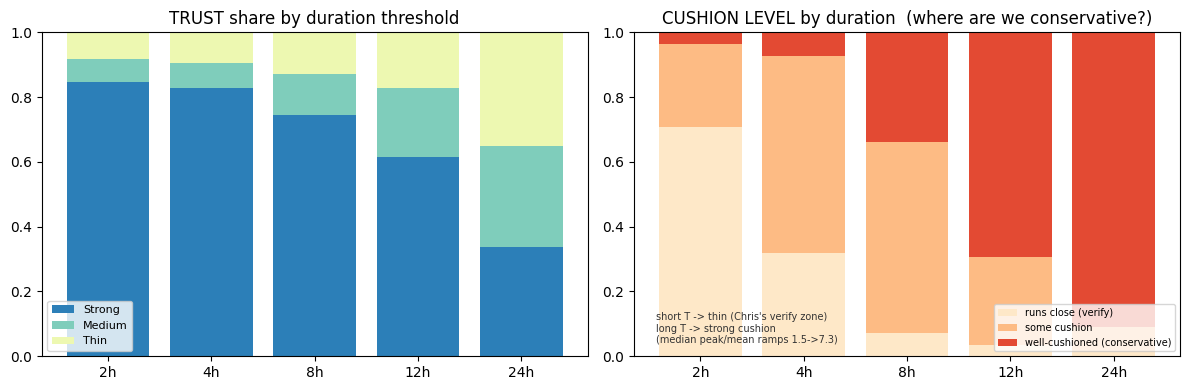

In [4]:
# ---------- viz: TRUST share (real finding) + spikiness ramp (real finding) ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = [str(t)+"h" for t in nat["T"]]
ax[0].bar(x, nat.strong, label="Strong", color="#2c7fb8")
ax[0].bar(x, nat.medium, bottom=nat.strong, label="Medium", color="#7fcdbb")
ax[0].bar(x, nat.thin, bottom=nat.strong+nat.medium, label="Thin", color="#edf8b1")
ax[0].set_title("TRUST share by duration threshold"); ax[0].set_ylim(0,1); ax[0].legend(loc="lower left", fontsize=8)
# RIGHT: CUSHION LEVEL by duration -- the direct answer to Chris's "conservative where?"
ax[1].bar(x, nat.cushion_thin, label="runs close (verify)", color="#fee8c8")
ax[1].bar(x, nat.cushion_mild, bottom=nat.cushion_thin, label="some cushion", color="#fdbb84")
ax[1].bar(x, nat.cushion_strong, bottom=nat.cushion_thin+nat.cushion_mild, label="well-cushioned (conservative)", color="#e34a33")
ax[1].set_title("CUSHION LEVEL by duration  (where are we conservative?)"); ax[1].set_ylim(0,1)
ax[1].legend(loc="lower right", fontsize=7)
ax[1].annotate("short T -> thin (Chris's verify zone)\nlong T -> strong cushion\n(median peak/mean ramps 1.5->7.3)",
               xy=(0.04, 0.04), xycoords="axes fraction", fontsize=7, color="#333")
plt.tight_layout(); plt.savefig(OUT+"/cell_read_shares_by_threshold.png", dpi=110); plt.show()

**Reading the figure.** *Left* — TRUST falls as duration rises (Strong 85% → 34%): longer
products are cleaner events but thinner-evidenced. *Right* — the **cushion level rises with
duration**: short-T cells (2h/4h) mostly *run close* — **Chris's "are we undercutting short
durations?" verify zone** — while 8h/12h+ are mostly *well-cushioned* (the ~2–3× A011
over-statement). That is the conservatism-by-threshold answer, driven by the peak/mean ramp
(median 1.5 → 7.3). The within-T **tilt** (spikier/flatter than peers) is a *secondary,
analyst-only* refinement in the per-county CSV — not a carrier-facing tag, and not a trend across T.

## Worked counties @ T = 8h — does the read discriminate?

Sanity-check against intuition: dense storm-driven counties should be **well-cushioned**
(spiky events); a source-gap county should be pulled to **Thin** trust by `C_source`; a county
with a handful of **flat** long outages should **run close** (little margin) — and if it's also
sparse, that's the double-caution cell.

In [5]:
WORKED = {48095:"Concho TX", 25027:"Worcester MA", 36029:"Erie NY",
          41025:"Harney OR", 25025:"Suffolk MA", 12001:"Alachua FL"}
w = base[(base["T"] == 8) & (base.fips.isin(WORKED))].copy()
w["county"] = w.fips.map(WORKED)
show = ["county","n_events_qualifying","n_obs_years","C_source","p2m_med","cushion_level",
        "p2m_pctile","cushion_tilt","TRUST","trust_lbl"]
print(w[show].sort_values("n_events_qualifying", ascending=False).round(2).to_string(index=False))

      county  n_events_qualifying  n_obs_years  C_source  p2m_med  cushion_level  p2m_pctile       cushion_tilt  TRUST trust_lbl
     Erie NY               2608.0           12      1.00     4.72 well-cushioned        0.95 spikier than peers   0.99    Strong
Worcester MA               2275.0           12      1.00     4.43 well-cushioned        0.93 spikier than peers   0.99    Strong
  Suffolk MA               1951.0           12      1.00     4.08 well-cushioned        0.90 spikier than peers   0.99    Strong
  Alachua FL               1546.0           12      1.00     4.57 well-cushioned        0.94 spikier than peers   0.75    Strong
   Concho TX                184.0           11      0.46     2.61   some cushion        0.50            typical   0.46      Thin
   Harney OR                 15.0            8      0.67     1.06     runs close        0.04 flatter than peers   0.43      Thin

## Flagged finding — exposure-denominator dilution (separate PRICING decision)

This notebook is diagnostic and changes no price. But building `C_source` surfaced a
real issue in the **rate itself** that deserves its own, validated pricing decision:

```text
 compute_per_customer_lambda.py uses ONE global observation_years (~11.17 yr)
 for EVERY county:   lambda_county = (n_events / 11.17) x S_T

   -> a county truly observed ~8 yrs still divides by 11.17  -> lambda ~1.4x too LOW
   -> direction = UNDER-price = ANTI-conservative
   -> it pulls OPPOSITE to the A011 cushion (which over-prices), so in poorly-covered
      counties the dilution EATS the cushion -- invisibly.
```

Registered as **A012** in `docs/methodology/assumptions.md`. The cell read shows the
*symptom* now (low `C_source` -> Thin). The *fix* — per-county observed-years in the
exposure denominator — is a real price move and is sequenced as its own item, not
slipped in here. The full per-year observed-vs-missing mask is the shared Step-3
prerequisite that upgrades both `C_source` and the denominator.

In [6]:
# ---------- persist outputs (notebooks/outputs/ is gitignored) ----------
keep = ["fips","T","cell_read","trust_lbl","cushion_level","cushion_tilt","TRUST","C_source","C_sample","C_evt",
        "p2m_med","p2m_pctile","share_spiky","share_mid","share_flat","evt_spread",
        "n_events_qualifying","n_obs_years","mm_ratio","pct_mcc_p90","pct_mcc_p99","coverage_gate_status"]
base[keep].to_csv(OUT+"/county_cell_read_by_threshold.csv", index=False)
nat.to_csv(OUT+"/national_cell_read_by_threshold.csv", index=False)
w[show].to_csv(OUT+"/worked_counties_cell_read.csv", index=False)
print("wrote:", OUT)
for f in ["county_cell_read_by_threshold.csv","national_cell_read_by_threshold.csv",
          "worked_counties_cell_read.csv","cell_read_shares_by_threshold.png"]:
    print("  -", f)

wrote: notebooks/outputs/inner_event_shape_diagnostics
  - county_cell_read_by_threshold.csv
  - national_cell_read_by_threshold.csv
  - worked_counties_cell_read.csv
  - cell_read_shares_by_threshold.png


## What this can and cannot prove

**Can support** (Gen-1, from event summaries):
- a per-cell TRUST read (source coverage + sample + eventization stability);
- a per-cell POSTURE read: cushion LEVEL (by-duration — the conservatism answer) + cushion TILT (within-T vs peers);
- routing: which cells are launch-ready, which need review, which to suppress.

**Cannot prove** from summaries alone:
- whether the *same* customers were out the whole event (true plateau vs churn) — `min` is degenerate (~1);
- the exact restoration curve — needs the 15-min paths preserved (later, targeted);
- the *magnitude* of the A011 cushion in absolute terms — that needs external per-customer
  duration data (the PowerOutage.US trial is the first shrink candidate).

**Decision rule:** posture is context + routing, **never** an automatic premium multiplier.

### Next
1. Wire the cell read into a generated artifact at the pricing grain (`fips x T`).
2. Build the shared per-year source-coverage mask (Step-3 prerequisite) -> upgrades `C_source` + the exposure denominator (A012).
3. Decide product-fit framing (which T to lead with) as a SEPARATE strategy axis, not part of TRUST.